In [47]:
import pandas as pd

df = pd.read_pickle(r"C:\Users\shash\Downloads\preprocessed_data.pkl")

In [48]:
df

,price,year,manufacturer,model,condition,number_of_cylinders,fuel_type,distance_driven_km,vehicle_title_status,transmission_type,drive_type,vehicle_size,vehicle_type,paint_color
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,23590,"2,019.00",nissan,maxima s sedan 4d,good,6 cylinders,gas,"32,226.00",clean,other,fwd,NaN,sedan,NaN
426876,30590,"2,020.00",volvo,s60 t5 momentum sedan 4d,good,NaN,gas,"12,029.00",clean,other,fwd,NaN,sedan,red
426877,34990,"2,020.00",cadillac,xt4 sport suv 4d,good,NaN,diesel,"4,174.00",clean,other,NaN,NaN,hatchback,white
426878,28990,"2,018.00",lexus,es 350 sedan 4d,good,6 cylinders,gas,"30,112.00",clean,other,fwd,NaN,sedan,silver


In [49]:
import pandas as pd

pd.options.display.float_format = "{:,.2f}".format

# 🚗 Exploratory Data Analysis (EDA) - Used Car Price Prediction

## 📌 Objective
The objective of Exploratory Data Analysis (EDA) is to understand the dataset, identify patterns, detect missing values and outliers, analyze relationships between variables, and prepare the data for building an accurate used car price prediction model.

---

# 📊 Exploratory Data Analysis (EDA) for Numerical Columns
### Numerical Columns

- **Price:** Selling price of the used car (Target Variable).
- **Distance_Driven_km:** Total distance the vehicle has traveled, measured in kilometers.

# 📈 EDA for Price

In [50]:

price_overview = pd.DataFrame({
    "Property": [
        "Shape",
        "First 5 Values",
        "Last 5 Values",
        "Random 5 Values",
        "Data Type",
        "Non-Missing Values",
        "Missing Values",
        "Unique Values"
    ],
    
    "Value": [
        df["price"].shape,
        df["price"].head().tolist(),
        df["price"].tail().tolist(),
        df["price"].sample(5, random_state=42).tolist(),
        df["price"].dtype,
        df["price"].count(),
        df["price"].isnull().sum(),
        df["price"].nunique()
    ]
})

price_overview

,Property,Value
0,Shape,"(426880,)"
1,First 5 Values,"[6000, 11900, 21000, 1500, 4900]"
2,Last 5 Values,"[23590, 30590, 34990, 28990, 30590]"
3,Random 5 Values,"[36990, 27995, 78423, 14000, 676]"
4,Data Type,int64
5,Non-Missing Values,426880
6,Missing Values,0
7,Unique Values,15655


In [51]:
statistics_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Minimum",
        "Maximum",
        "Range",
        "Variance",
        "Standard Deviation",
        "Interquartile Range (IQR)",
        "Skewness",
        "Kurtosis"
    ],

    "Value": [
        round(df["price"].mean(), 2),
        round(df["price"].median(), 2),
        round(df["price"].mode().iloc[0], 2),
        round(df["price"].min(), 2),
        round(df["price"].max(), 2),
        round(df["price"].max() - df["price"].min(), 2),
        round(df["price"].var(), 2),
        round(df["price"].std(), 2),
        round(df["price"].quantile(0.75) - df["price"].quantile(0.25), 2),
        round(df["price"].skew(), 2),
        round(df["price"].kurt(), 2)
    ]
})

statistics_summary

,Statistic,Value
0,Mean,"75,199.03"
1,Median,"13,950.00"
2,Mode,0.00
3,Minimum,0.00
4,Maximum,"3,736,928,711.00"
5,Range,"3,736,928,711.00"
6,Variance,"148,407,998,957,162.50"
7,Standard Deviation,"12,182,282.17"
8,Interquartile Range (IQR),"20,585.75"
9,Skewness,254.41


# Outlier Detection and Analysis

## 📌 Key Observations

- The **mean price is significantly higher than the median**, indicating that the price distribution is **highly right-skewed**.

- The **mode of the price column is 0**, suggesting the presence of invalid, missing, or incorrectly recorded price values that require further investigation.

- The **minimum price is also 0**, which is unrealistic for a used car and may indicate data quality issues.

- The **maximum price is extremely high (3,736,928,711)**, indicating the presence of one or more extreme outliers or possible data entry errors.

- The **large range between the minimum and maximum prices** shows that the dataset contains a wide variation in car prices.

- The **high standard deviation** indicates that the price values are widely dispersed around the mean.

- The **Interquartile Range (IQR) is relatively small compared to the overall range**, suggesting that most cars fall within a relatively narrow price range while a few extreme values stretch the distribution.

- The **very high skewness value (254.41)** confirms that the distribution is **extremely positively skewed**, with a small number of high-priced vehicles heavily influencing the average price.

- The **very high kurtosis value (69,205.09)** indicates the presence of **extreme outliers and heavy tails** in the price distribution.

- Overall, the **price column contains potential outliers and possible data quality issues** that should be investigated and treated before feature engineering and model training.

In [52]:
five_number_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "First Quartile (Q1)",
        "Median (Q2)",
        "Third Quartile (Q3)",
        "Maximum"
    ],
    "Value": [
        df["price"].min(),
        df["price"].quantile(0.25),
        df["price"].median(),
        df["price"].quantile(0.75),
        df["price"].max()
    ]
})

five_number_summary

,Statistic,Value
0,Minimum,0.00
1,First Quartile (Q1),"5,900.00"
2,Median (Q2),"13,950.00"
3,Third Quartile (Q3),"26,485.75"
4,Maximum,"3,736,928,711.00"


### Observation: Price Distribution

- The **`price`** feature is **highly right-skewed**, indicating that most cars are priced within a relatively small range, while a few cars have extremely high prices.
- The histogram and box plot reveal the presence of **several extreme outliers** on the higher end of the price distribution.
- Approximately **32,985 records have a price of 0**.
- Since a selling price of **0 is unrealistic for a car**, these values may represent **missing prices, unavailable prices, or data entry issues**.
- Further investigation is required before deciding whether to remove, impute, or retain these records for model building.

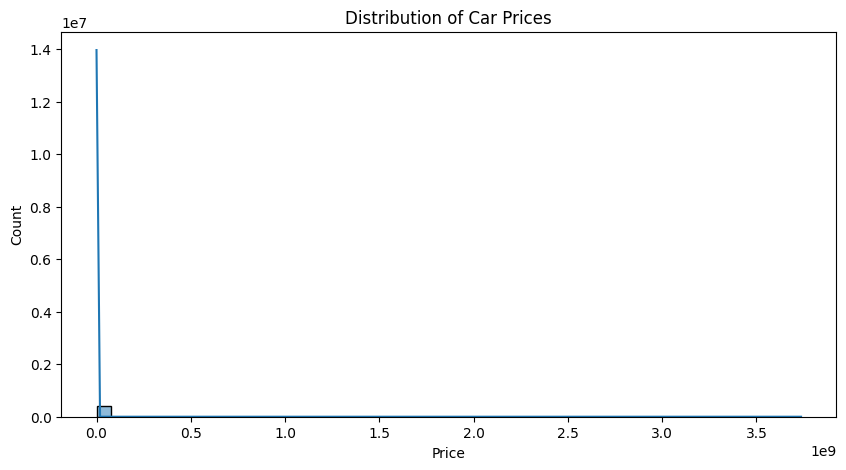

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

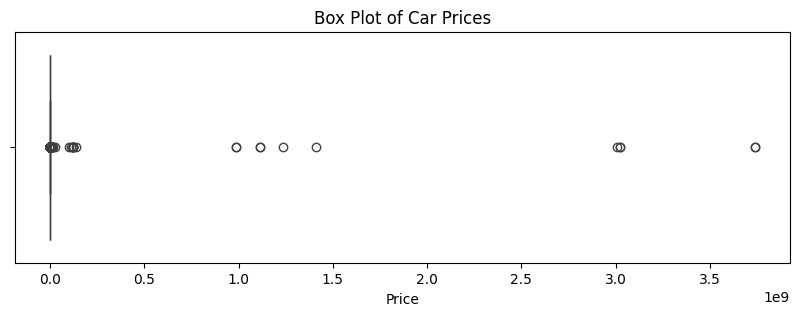

In [54]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["price"])
plt.title("Box Plot of Car Prices")
plt.xlabel("Price")
plt.show()

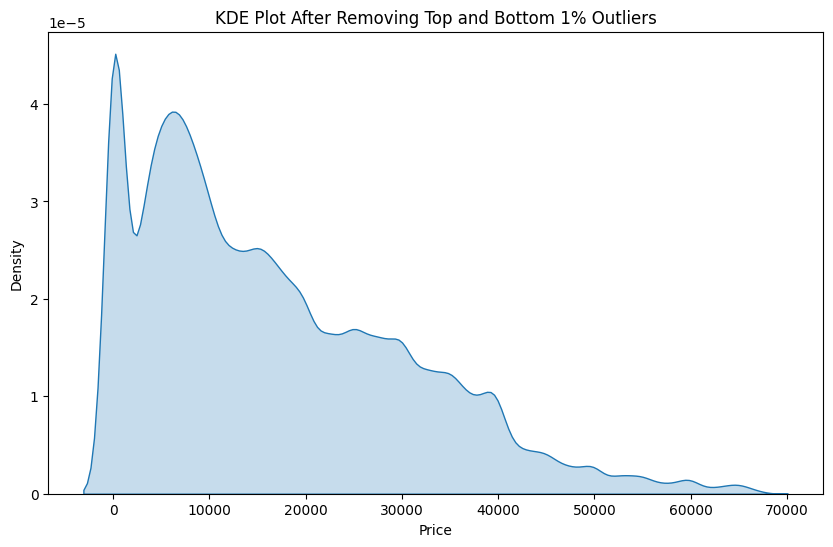

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the top and bottom 1% outliers
lower_limit = df["price"].quantile(0.01)
upper_limit = df["price"].quantile(0.99)

df_no_outliers = df[
    (df["price"] >= lower_limit) &
    (df["price"] <= upper_limit)
]

# KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df_no_outliers["price"], fill=True)

plt.title("KDE Plot After Removing Top and Bottom 1% Outliers")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

## Checking Whether Cars with Zero Price Are Suspicious

To determine whether the cars with a price of **0** are suspicious, we perform a detailed analysis of these records. The objective is to identify whether a zero price represents a genuine listing, missing information, data-entry errors, or an anomaly in the dataset.

The following checks are performed:

- Count the total number of cars with a price equal to 0 
- Determine whether zero prices are realistic or indicate invalid observations.

Based on this analysis, an appropriate decision will be made regarding whether these records should be retained, imputed, or removed from the dataset.

In [56]:
df.loc[df["price"] == 0, ["vehicle_title_status", "condition"]]["vehicle_title_status"].value_counts()

vehicle_title_status
clean         32250
rebuilt          79
salvage          31
missing          17
parts only        9
lien              1
Name: count, dtype: int64

In [57]:
df.loc[df["price"] == 0, ["vehicle_title_status", "condition"]]["condition"].value_counts()

condition
excellent    6542
good         2301
like new     1118
new           173
fair           40
salvage         6
Name: count, dtype: int64

### Observation: Relationship between Price = 0 and Vehicle Condition

- The majority of vehicles with a price of **0** have a **Clean** title status.
- Most of these vehicles are also listed in **Excellent**, **Good**, or **Like New** condition.
- Therefore, there is **no strong evidence** to suggest that vehicles have a price of **0** because they are damaged or in poor condition.
- This indicates that a price of **0** is more likely to represent **missing, unavailable, or incorrectly recorded price information** rather than the actual selling price of the vehicle.

In [58]:
import numpy as np
df["price"] = df["price"].replace(0, np.nan)

# Imputing Missing Values Using Different Techniques

## Complete Case Analysis (CCA)

Before applying **Complete Case Analysis (CCA)**, the missing data is carefully analyzed to determine whether CCA is an appropriate imputation technique.

The following checks are performed:

- Calculate the **total percentage of missing values** in the dataset.
- Assess whether the missing values are **Missing Completely At Random (MCAR)**.
- Compare the distribution of the feature **before and after applying CCA** to evaluate whether removing missing observations introduces any significant bias.

Based on these analyses, a decision is made regarding the suitability of Complete Case Analysis for handling the missing values in the dataset.

In [59]:
df["price"].isnull().mean()*100

np.float64(7.7059126686656665)

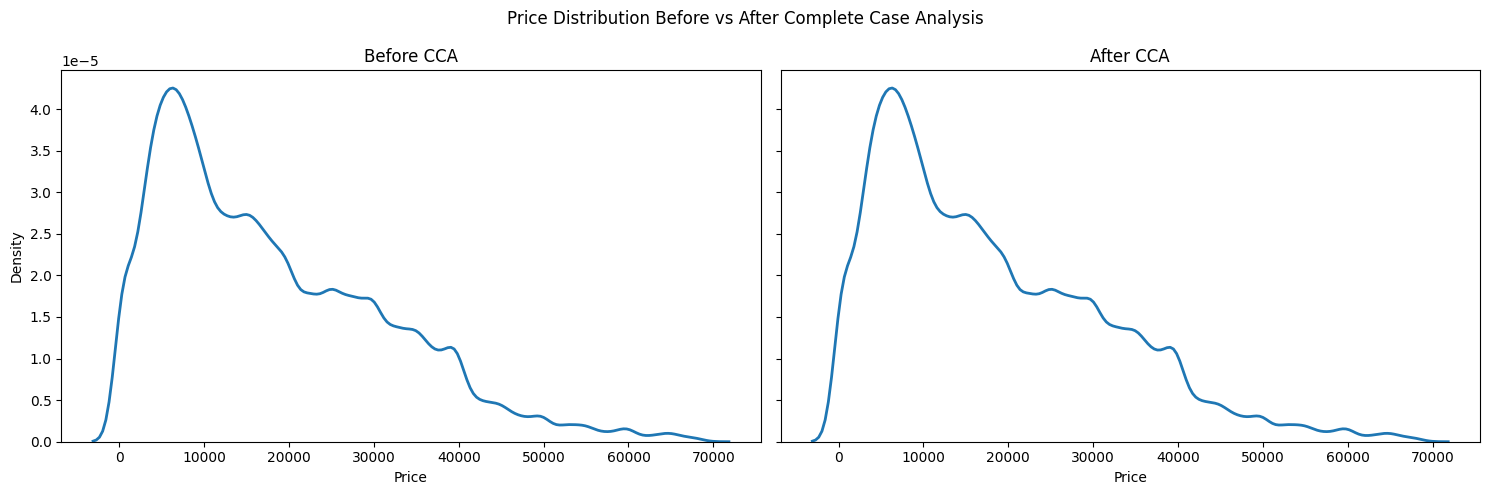

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 99th percentile cutoff
upper = df["price"].quantile(0.99)

# Before CCA
before = df.loc[df["price"] <= upper, "price"]

# After CCA
df_cca = df.dropna(subset=["price"])
after = df_cca.loc[df_cca["price"] <= upper, "price"]

# Side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Before CCA
sns.kdeplot(before, ax=ax[0], linewidth=2)
ax[0].set_title("Before CCA")
ax[0].set_xlabel("Price")
ax[0].set_ylabel("Density")

# After CCA
sns.kdeplot(after, ax=ax[1], linewidth=2)
ax[1].set_title("After CCA")
ax[1].set_xlabel("Price")
ax[1].set_ylabel("Density")

plt.suptitle("Price Distribution Before vs After Complete Case Analysis")
plt.tight_layout()
plt.show()

## Results of Complete Case Analysis (CCA)

The following observations were obtained after applying **Complete Case Analysis (CCA)**:

- Approximately **7.7%** of the observations contained missing values and were removed using CCA.
- The distribution of the **`price`** feature **before and after applying CCA** remained almost identical.
- The histogram and KDE plots showed that the overall shape, skewness, and density of the `price` feature were preserved after removing the missing observations.
- This indicates that applying Complete Case Analysis **did not introduce any noticeable bias** into the distribution of the `price` feature.
- Based on these observations, **Complete Case Analysis appears to be a suitable approach** for handling the missing values in this dataset.

> **Note:** Although the distribution remained unchanged after applying CCA, this visual evidence alone does **not** prove that the missing values are **Missing Completely At Random (MCAR)**. A formal statistical test (e.g., Little's MCAR test) would be required to validate the MCAR assumption.

## KNN Imputer

## Why KNN Imputer Was Not Used

Although **KNN Imputer** is an advanced missing value imputation technique, it was **not applied** to this dataset due to the following reasons:

### 1. Large Dataset Size
- The dataset contains **426,880 rows** and **14 features**.
- KNN Imputer computes the distance between observations to identify the nearest neighbors for every missing value.
- On such a large dataset, this process becomes **computationally expensive** and requires significant execution time and memory.

### 2. High Number of Missing Values
- Total missing values in the dataset: **1,087,005**
- Overall missing percentage: **18.19%**

Although KNN can handle moderate missing values, applying it to over one million missing entries would considerably increase computation time.

### 3. Presence of Many Categorical Features
The dataset contains several categorical variables, such as:
- manufacturer
- model
- condition
- fuel_type
- transmission_type
- drive_type
- vehicle_size
- vehicle_type
- paint_color

KNN Imputer is primarily designed for **numerical features**. These categorical variables would first need to be encoded into numerical form. After encoding, the distance calculations may not accurately represent the true similarity between observations, which can reduce the quality of imputation.

### 4. Better Alternative
For this dataset, a simpler and more scalable approach was preferred:
- **Mean Imputation** for numerical features with approximately normal distributions.
- **Median Imputation** for skewed numerical features.
- **Mode (Most Frequent) Imputation** for categorical features.

This approach is computationally efficient, scalable to large datasets, and is widely used in real-world machine learning pipelines.

### Conclusion
Since the dataset is large, contains over **1 million missing values**, and includes many categorical features, **KNN Imputer was not selected**. Simpler statistical imputation methods (Mean, Median, and Mode) provide a faster and more practical solution while maintaining good model performance.

In [61]:
df.isnull().sum().sum()

np.int64(1087005)

## Why Iterative Imputer Was Not Applied

Although **Iterative Imputer** is a powerful missing value imputation technique, it was **not used** for this dataset due to the following reasons.

### 1. Missing Data is MCAR
- The missing data mechanism in this dataset was identified as **Missing Completely At Random (MCAR)**.
- In MCAR, the probability of a value being missing is **independent of both the observed and unobserved data**.
- Since the missingness is completely random, there is no strong relationship between the missing values and other features for the Iterative Imputer to exploit.
- Therefore, simpler statistical imputation methods such as **Mean, Median, and Mode** are generally sufficient and more appropriate.

### 2. Very Large Dataset
- The dataset contains **426,880 rows** and **14 features**.
- Iterative Imputer repeatedly trains prediction models for every feature containing missing values.
- On a dataset of this size, the imputation process becomes computationally expensive and time-consuming.

### 3. Large Number of Missing Values
- Total missing values: **1,087,005**
- Missing value percentage: **18.19%**

Handling more than one million missing values through repeated model training significantly increases the computational cost.

### 4. Multiple Prediction Models are Required
- There are **14 features containing missing values**.
- Iterative Imputer trains **one predictive model for each feature** with missing values during every iteration.
- With the default `max_iter=10`, approximately:

  **14 models × 10 iterations = 140 model fits**

Each model is trained on more than **426,000 observations**, making the overall process computationally intensive.

### 5. High Memory Consumption
- Iterative Imputer stores intermediate imputed values and repeatedly updates them during each iteration.
- This increases memory usage, especially for large datasets.

### 6. Presence of Numerous Categorical Features
The dataset contains several categorical variables, including:
- manufacturer
- model
- condition
- fuel_type
- transmission_type
- drive_type
- vehicle_size
- vehicle_type
- paint_color

These features must be encoded before model training, increasing preprocessing complexity and computational cost.

### Conclusion
Since the dataset follows an **MCAR** missingness mechanism, contains **426,880 rows**, has **1,087,005 missing values (18.19%)**, and would require repeated training of **140 predictive models**, **Iterative Imputer was not considered an appropriate choice**. Simpler statistical imputation methods (Mean, Median, and Mode) are computationally efficient, scalable, and well-suited for this dataset.

## Handling Missing Values in the Target Variable (`price`)

The `price` column is the **target variable** for this car price prediction task. Since the target variable represents the value that the machine learning model is expected to predict, records with missing target values cannot be used for supervised learning.

Instead of imputing the missing values, all rows with missing values in the `price` column were removed for the following reasons:

- The true selling price of these vehicles is unknown, making it impossible to verify the correctness of any imputed value.
- Imputing the target variable (using mean, median, KNN, or any other technique) would introduce artificial labels into the dataset, which can bias the model and reduce its predictive reliability.
- Supervised machine learning algorithms require the target variable to be known during training. Records with missing target values do not contribute meaningful information for model learning.
- Removing rows with missing target values preserves the integrity and reliability of the training dataset by ensuring that the model learns only from actual observed prices.

Therefore, all records with missing values in the `price` column were removed before proceeding with further preprocessing and model development.

In [62]:

df = df.dropna(subset=["price"])

# Reset the index
df.reset_index(drop=True, inplace=True)

# Verify that no missing values remain in the target column
print("Missing values in price:", df["price"].isnull().sum())
print("New dataset shape:", df.shape)

Missing values in price: 0
New dataset shape: (393985, 14)


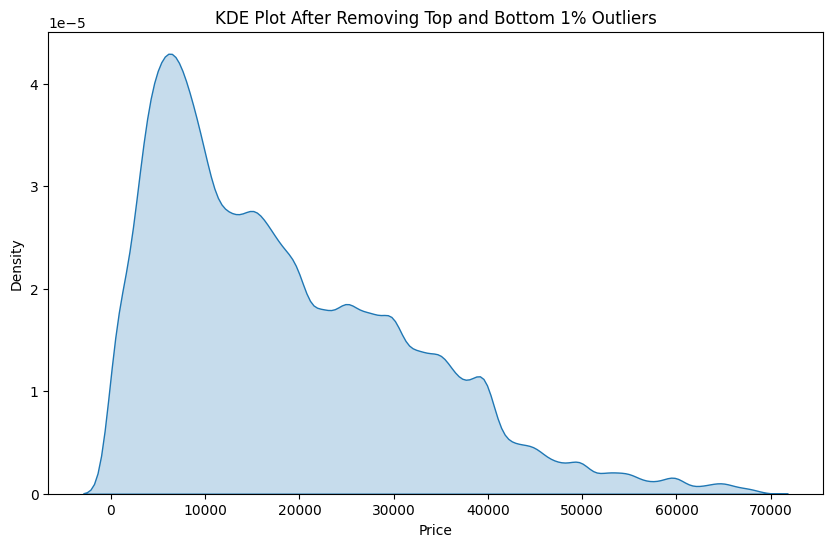

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the top and bottom 1% outliers
lower_limit = df["price"].quantile(0.01)
upper_limit = df["price"].quantile(0.99)

df_no_outliers = df[
    (df["price"] >= lower_limit) &
    (df["price"] <= upper_limit)
]

# KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df_no_outliers["price"], fill=True)

plt.title("KDE Plot After Removing Top and Bottom 1% Outliers")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

### Outlier Detection

Since the distribution of the `price` column is **right-skewed**, the **box plot (IQR) method** is used to detect outliers. The box plot identifies observations that lie beyond the typical range of the data based on the interquartile range (IQR). This method is robust to skewed distributions and is widely used during exploratory data analysis to identify extreme values without being overly influenced by them.

In [64]:
# Calculate Q1, Q3, and IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Lower Bound: -23885.0
Upper Bound: 58475.0
Number of Outliers: 7779


In [65]:
df[df["price"] >= 1_000_000].sort_values(ascending=False,by="price")

,price,year,manufacturer,model,condition,number_of_cylinders,fuel_type,distance_driven_km,vehicle_title_status,transmission_type,drive_type,vehicle_size,vehicle_type,paint_color
329372,"3,736,928,711.00","1,999.00",toyota,4runner,fair,6 cylinders,gas,"211,000.00",clean,automatic,4wd,mid-size,NaN,green
294861,"3,736,928,711.00","2,007.00",toyota,tundra,excellent,8 cylinders,gas,"164,000.00",clean,automatic,4wd,full-size,pickup,silver
83659,"3,024,942,282.00","2,000.00",mercedes-benz,benz e320,NaN,NaN,gas,"100,000.00",clean,automatic,NaN,NaN,NaN,NaN
239723,"3,024,942,282.00","2,000.00",mercedes-benz,benz s430,NaN,NaN,gas,"100,000.00",clean,automatic,NaN,NaN,NaN,NaN
33582,"3,009,548,743.00","2,021.00",chevrolet,NaN,NaN,8 cylinders,gas,"1,000.00",clean,automatic,4wd,NaN,NaN,NaN
171418,"1,410,065,407.00","1,989.00",jeep,wrangler,NaN,NaN,diesel,"103,000.00",clean,manual,NaN,NaN,SUV,NaN
141671,"1,234,567,890.00","2,006.00",volvo,vnl,fair,NaN,other,"200,000.00",clean,manual,NaN,NaN,NaN,black
26782,"1,111,111,111.00","1,999.00",ford,f350 super duty lariat,good,8 cylinders,diesel,"149,000.00",clean,automatic,rwd,full-size,pickup,white
33581,"1,111,111,111.00","2,020.00",jeep,NaN,NaN,NaN,gas,"1,000.00",clean,automatic,4wd,NaN,NaN,NaN
266,"987,654,321.00","1,960.00",chevrolet,NaN,NaN,NaN,gas,"999,999.00",clean,manual,NaN,NaN,NaN,NaN


## Analysis of Vehicles Priced Above $100,000

After analyzing the vehicles with prices greater than \$100,000, it was observed that most of these vehicles belong to brands such as Chrysler, GMC, Chevrolet, and Ford. These manufacturers are primarily known for producing mass-market vehicles rather than ultra-luxury or exotic cars.

Since these brands do not typically manufacture million-dollar luxury vehicles, such unusually high prices are likely the result of data-entry errors, placeholder values, or anomalies in the dataset. Therefore, these observations can be treated as suspicious outliers and should be investigated further or removed before model training.

In [66]:
df[df["price"]>100000]["manufacturer"].value_counts()

manufacturer
chevrolet        103
mercedes-benz     71
ferrari           42
ford              38
porsche           34
audi              30
dodge             26
cadillac          21
ram               20
rover             16
jeep              10
bmw                7
acura              5
nissan             4
jaguar             4
toyota             4
gmc                4
aston-martin       3
chrysler           3
buick              3
volkswagen         2
volvo              2
lincoln            2
lexus              2
tesla              2
subaru             2
honda              1
saturn             1
pontiac            1
Name: count, dtype: int64

In [67]:
brands = ["chrysler", "gmc", "chevrolet", "ford"]

median_df = (
    df[df["manufacturer"].isin(brands)]
    .groupby("manufacturer")["price"]
    .median()
    .reset_index()
)

median_df.columns = ["manufacturer", "median_price"]

median_df

,manufacturer,median_price
0,chevrolet,"15,990.00"
1,chrysler,"7,995.00"
2,ford,"16,995.00"
3,gmc,"23,990.00"


## Removing Vehicles With Prices Greater Than $100,000

After analyzing the target variable (`price`), we observed that a large number of vehicles with prices exceeding \$100,000 belong to mass-market brands that do not typically manufacture ultra-luxury or million-dollar vehicles.

For example:

- Chevrolet Silverado 1500
- Chevrolet Malibu
- Chevrolet Sonic
- Chrysler 300
- Chrysler Town & Country
- GMC Sierra

These vehicles are generally priced in the range of \$5,000–\$50,000 in the second-hand market. Therefore, prices above \$100,000 for such models are highly suspicious and are likely the result of data-entry errors or anomalies in the dataset.

Moreover, since `price` is the target variable, imputing these values using the mean or median is not appropriate. The target variable is the quantity that the model is supposed to learn and predict. Replacing suspicious target values with statistical measures such as the mean or median may introduce bias into the model and negatively affect its performance.

Therefore, all vehicles with prices greater than \$100,000 are removed from the dataset to improve data quality and ensure reliable model training.

In [77]:
df = df[df["price"] <= 1000000]

<Axes: xlabel='price', ylabel='Density'>

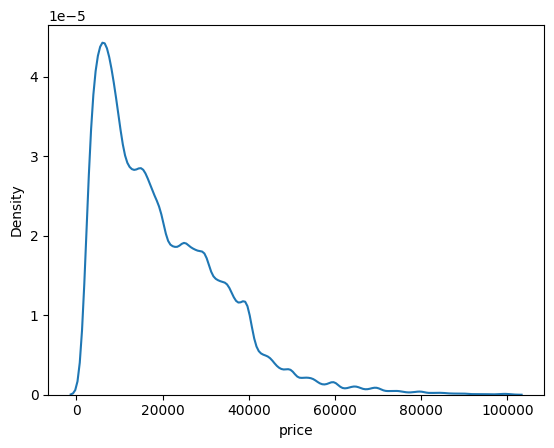

In [78]:
sns.kdeplot(df["price"])

In [82]:
df["price"].sort_values()

187931     2,000.00
225667     2,000.00
113492     2,000.00
113494     2,000.00
113495     2,000.00
            ...    
139168   100,000.00
304302   100,000.00
179168   100,000.00
312567   100,000.00
380872   100,000.00
Name: price, Length: 373248, dtype: float64

In [72]:
df["price"].sort_values()

442            1.00
88513          1.00
119995         1.00
88512          1.00
296010         1.00
            ...    
56891    100,000.00
380872   100,000.00
356247   100,000.00
179168   100,000.00
209517   100,000.00
Name: price, Length: 393330, dtype: float64

In [73]:
high_price_cars = df[df["price"] > 550000]

high_price_cars["manufacturer"].value_counts()

Series([], Name: count, dtype: int64)

In [74]:
df[df["price"] < 2000][["model", "year", "price"]]

,model,year,price
3,NaN,NaN,"1,500.00"
5,NaN,NaN,"1,600.00"
6,NaN,NaN,"1,000.00"
21,NaN,NaN,500.00
90,NaN,"2,004.00",80.00
...,...,...,...
393108,1500,"1,998.00","1,600.00"
393127,f-150,"1,995.00",950.00
393149,4runner,"1,997.00","1,800.00"
393200,deville,"2,000.00",800.00


In [75]:
df = df[df["price"] >= 2000]

<Axes: xlabel='price', ylabel='Density'>

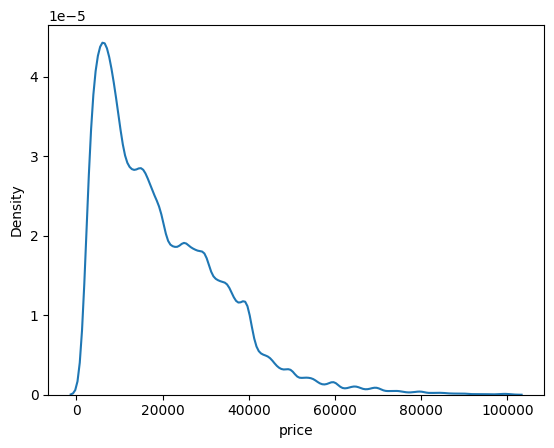

In [76]:
sns.kdeplot(df["price"])